# Assessment 2: Pemodelan Machine Learning (Klasifikasi & Klastering) — Revisi

**Dataset:** New York City Airbnb 2019

Notebook ini berisi implementasi lengkap dari pipa pemrosesan data (preprocessing pipeline), pemodelan Supervised Learning (Klasifikasi Popularitas), dan Unsupervised Learning (Klastering Geografis & Ekonomi) dengan validasi silang, penyetelan ambang keputusan, dan pemilihan konfigurasi klastering secara objektif.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, f1_score,
    roc_curve, precision_recall_curve,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.inspection import permutation_importance
from IPython.display import Markdown, display
import joblib

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

def section(title):
    display(Markdown(f"## {title}"))

def ask_plot(question):
    display(Markdown(f"**Pertanyaan grafik:** {question}"))

def explain_plot(points):
    display(Markdown(f"**Interpretasi:**\n" + "\n".join(f"- {p}" for p in points)))

def fmt_num(x, digits=2):
    if pd.isna(x):
        return "NA"
    if abs(x) >= 1000:
        return f"{x:,.{digits}f}"
    return f"{x:.{digits}f}"


In [2]:
# Unduh / muat dataset dengan fallback ke file lokal
selected_cols = [
    "id", "host_id",
    "neighbourhood_group", "neighbourhood",
    "latitude", "longitude",
    "room_type",
    "price", "minimum_nights",
    "number_of_reviews", "last_review", "reviews_per_month",
    "calculated_host_listings_count", "availability_365",
]

try:
    path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
    csv_path = f"{path}/AB_NYC_2019.csv"
    print(f"[kagglehub] Dataset diunduh: {path}")
except Exception:
    csv_path = "AB_NYC_2019.csv"
    print(f"[local] Menggunakan file lokal: {csv_path}")

df_raw = pd.read_csv(csv_path, usecols=selected_cols, parse_dates=["last_review"])

# Filter data tidak valid
mask_valid = (
    (df_raw["price"] > 0)
    & (df_raw["availability_365"].between(0, 365))
    & (df_raw["latitude"].between(40.45, 40.95))
    & (df_raw["longitude"].between(-74.30, -73.65))
)
df = df_raw.loc[mask_valid].copy()

print(f"Baris setelah pembersihan: {len(df):,}")
print(f"Baris terbuang: {len(df_raw) - len(df):,}")


[kagglehub] Dataset diunduh: C:\Users\erlanggadewa\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3
Baris setelah pembersihan: 48,884
Baris terbuang: 11


## Rekayasa Fitur (Feature Engineering)


In [3]:
section("Rekayasa Fitur Baru")

# 1. Log-transform untuk fitur dengan skew ekstrem
df["log_price"] = np.log1p(df["price"])
df["log_min_nights"] = np.log1p(df["minimum_nights"])

# 2. Usia ulasan terakhir (hari sejak review terbaru)
ref_date = df["last_review"].max()
df["last_review_age_days"] = (ref_date - df["last_review"]).dt.days
df["last_review_age_days"] = df["last_review_age_days"].fillna(1825)

# 3. Flag properti yang pernah diulas
df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)

# 4. Jarak ke pusat Manhattan (Times Square) — haversine
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

TIMES_SQ = (40.7580, -73.9855)
df["distance_to_center_km"] = haversine_np(df["latitude"], df["longitude"], *TIMES_SQ)

# 5. Cap outlier pada persentil 99
p99_avail = df["availability_365"].quantile(0.99)
p99_min_nights = df["minimum_nights"].quantile(0.99)
df["availability_365_capped"] = df["availability_365"].clip(upper=p99_avail)
df["minimum_nights_capped"] = df["minimum_nights"].clip(upper=p99_min_nights)

# 6. Log-transform jumlah ulasan historis
df["log_number_of_reviews"] = np.log1p(df["number_of_reviews"])

# Tampilkan ringkasan fitur baru
new_cols = [
    "log_price", "log_min_nights", "last_review_age_days",
    "has_reviews", "distance_to_center_km",
    "availability_365_capped", "log_number_of_reviews",
]
display(df[new_cols].describe().round(2))

ask_plot("Apa nilai tambah fitur-fitur rekayasa ini dibandingkan data mentah?")
explain_plot([
    f"Fitur `last_review_age_days` dan `has_reviews` mengubah 'missing value' menjadi sinyal bisnis nyata: properti yang belum pernah diulas tidak memiliki riwayat aktivitas.",
    f"`log_price` dan `log_min_nights` meredam skew ekstrem (>$10,000/malam, >1,000 malam) agar model regresi dan klastering tidak didominasi pencilan.",
    f"`distance_to_center_km` merangkum koordinat lat/lon menjadi satu dimensi geografis yang linier dan mudah diinterpretasi.",
    f"`log_number_of_reviews` membawa sinyal riwayat popularitas — properti dengan 500 ulasan berbeda karakternya dari yang 0 ulasan.",
])


## Rekayasa Fitur Baru

,log_price,log_min_nights,last_review_age_days,has_reviews,distance_to_center_km,availability_365_capped,log_number_of_reviews
count,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00
mean,4.74,1.50,595.24,0.79,7.11,112.78,1.99
std,0.69,0.87,726.33,0.40,4.44,131.63,1.56
min,2.40,0.69,0.00,0.00,0.07,0.00,0.00
25%,4.25,0.69,19.00,1.00,3.82,0.00,0.69
50%,4.67,1.39,186.00,1.00,6.39,45.00,1.79
75%,5.17,1.79,1201.00,1.00,9.42,227.00,3.22
max,9.21,7.13,3024.00,1.00,35.90,365.00,6.45


**Pertanyaan grafik:** Apa nilai tambah fitur-fitur rekayasa ini dibandingkan data mentah?

**Interpretasi:**
- Fitur `last_review_age_days` dan `has_reviews` mengubah 'missing value' menjadi sinyal bisnis nyata: properti yang belum pernah diulas tidak memiliki riwayat aktivitas.
- `log_price` dan `log_min_nights` meredam skew ekstrem (>$10,000/malam, >1,000 malam) agar model regresi dan klastering tidak didominasi pencilan.
- `distance_to_center_km` merangkum koordinat lat/lon menjadi satu dimensi geografis yang linier dan mudah diinterpretasi.
- `log_number_of_reviews` membawa sinyal riwayat popularitas — properti dengan 500 ulasan berbeda karakternya dari yang 0 ulasan.

## Pembuatan Target Klasifikasi


In [4]:
section("Target: is_popular (Q75)")

# Isi NaN di reviews_per_month dengan 0 (fakta bisnis: belum pernah dipesan)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Ambang batas Q75
q75 = df["reviews_per_month"].quantile(0.75)
df["is_popular"] = (df["reviews_per_month"] >= q75).astype(int)

print(f"Ambang batas popularitas (Q75): {q75:.3f} ulasan/bulan")
print("\nDistribusi kelas target:")
display(df["is_popular"].value_counts(normalize=True).mul(100).round(2).to_frame("Persentase (%)"))

ask_plot("Apakah distribusi target masih timpang (imbalanced)?")
explain_plot([
    f"Dengan ambang Q75, sekitar {fmt_num(df['is_popular'].mean() * 100)}% properti masuk kategori 'Popular'.",
    "Rasio ~75:25 adalah ketidakseimbangan moderat yang ditangani dengan `class_weight='balanced'` pada setiap classifier.",
])


## Target: is_popular (Q75)

Ambang batas popularitas (Q75): 1.580 ulasan/bulan

Distribusi kelas target:


,Persentase (%)
is_popular,
0,74.87
1,25.13


**Pertanyaan grafik:** Apakah distribusi target masih timpang (imbalanced)?

**Interpretasi:**
- Dengan ambang Q75, sekitar 25.13% properti masuk kategori 'Popular'.
- Rasio ~75:25 adalah ketidakseimbangan moderat yang ditangani dengan `class_weight='balanced'` pada setiap classifier.

## Pipa Preprocessing & Pemisahan Data


In [5]:
section("Pipa Preprocessing")

# Fitur numerik hasil rekayasa
numeric_features = [
    "latitude", "longitude",
    "log_price", "log_min_nights",
    "availability_365_capped",
    "last_review_age_days",
    "has_reviews",
    "log_number_of_reviews",
    "distance_to_center_km",
]

# Fitur kategorikal
categorical_features = ["neighbourhood_group", "room_type"]

# Pemisahan fitur dan target
feature_cols = numeric_features + categorical_features
X = df[feature_cols].copy()
y = df["is_popular"]

# ColumnTransformer untuk scaling + encoding
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

# Stratified split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test:  {X_test.shape}")
print(f"Rasio kelas di train: {y_train.mean():.3f}")
print(f"Rasio kelas di test:  {y_test.mean():.3f}")


## Pipa Preprocessing

Dimensi X_train: (39107, 11)
Dimensi X_test:  (9777, 11)
Rasio kelas di train: 0.251
Rasio kelas di test:  0.251


## Klasifikasi: Validasi Silang Tiga Model


In [6]:
section("Validasi Silang 5-Fold — Random Forest, Logistic Regression, HistGradientBoosting")

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )),
])

lr_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=2000, C=1.0, random_state=RANDOM_STATE
    )),
])

hgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=None,
        class_weight="balanced", random_state=RANDOM_STATE
    )),
])

models = {
    "Random Forest": rf_pipe,
    "Logistic Regression": lr_pipe,
    "HistGradientBoosting": hgb_pipe,
}

# 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "average_precision", "f1"]

cv_results = []
for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring)
    cv_results.append({
        "Model": name,
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        "PR-AUC": f"{scores['test_average_precision'].mean():.4f} ± {scores['test_average_precision'].std():.4f}",
        "F1": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
    })

cv_df = pd.DataFrame(cv_results)
display(cv_df)

# Pilih model terbaik berdasarkan PR-AUC
pr_auc_means = [float(r.split(" ± ")[0]) for r in cv_df["PR-AUC"]]
best_idx = np.argmax(pr_auc_means)
best_name = cv_df.loc[best_idx, "Model"]
best_pipe = models[best_name]

display(Markdown(f"**Model terbaik berdasarkan PR-AUC CV:** {best_name}"))

ask_plot("Model mana yang paling andal membedakan properti populer vs tidak populer?")
explain_plot([
    f"**{best_name}** unggul dalam PR-AUC dan F1 — metrik yang jujur untuk data timpang.",
    "Random Forest dan HistGradientBoosting unggul menangkap interaksi non-linear antar fitur dibanding Logistic Regression.",
    "PR-AUC fokus pada performa kelas minoritas (Popular), lebih relevan daripada ROC-AUC untuk kasus imbalance.",
])


## Validasi Silang 5-Fold — Random Forest, Logistic Regression, HistGradientBoosting

,Model,ROC-AUC,PR-AUC,F1
0,Random Forest,0.9618 ± 0.0024,0.8793 ± 0.0095,0.8123 ± 0.0066
1,Logistic Regression,0.9389 ± 0.0026,0.8279 ± 0.0093,0.7485 ± 0.0044
2,HistGradientBoosting,0.9615 ± 0.0021,0.8805 ± 0.0079,0.8028 ± 0.0059


**Model terbaik berdasarkan PR-AUC CV:** HistGradientBoosting

**Pertanyaan grafik:** Model mana yang paling andal membedakan properti populer vs tidak populer?

**Interpretasi:**
- **HistGradientBoosting** unggul dalam PR-AUC dan F1 — metrik yang jujur untuk data timpang.
- Random Forest dan HistGradientBoosting unggul menangkap interaksi non-linear antar fitur dibanding Logistic Regression.
- PR-AUC fokus pada performa kelas minoritas (Popular), lebih relevan daripada ROC-AUC untuk kasus imbalance.

## Penyetelan Ambang Keputusan (Threshold Tuning) & Evaluasi 3 Model

### Classification Report — Random Forest

Threshold optimal  : 0.4902 | F1-score: 0.8173
               precision    recall  f1-score   support

Tidak Popular       0.96      0.90      0.93      7320
      Popular       0.76      0.89      0.82      2457

     accuracy                           0.90      9777
    macro avg       0.86      0.90      0.87      9777
 weighted avg       0.91      0.90      0.90      9777



### Classification Report — Logistic Regression

Threshold optimal  : 0.5145 | F1-score: 0.7476
               precision    recall  f1-score   support

Tidak Popular       0.97      0.82      0.89      7320
      Popular       0.63      0.92      0.75      2457

     accuracy                           0.84      9777
    macro avg       0.80      0.87      0.82      9777
 weighted avg       0.88      0.84      0.85      9777



### Classification Report — HistGradientBoosting

Threshold optimal  : 0.6351 | F1-score: 0.8167
               precision    recall  f1-score   support

Tidak Popular       0.97      0.89      0.93      7320
      Popular       0.74      0.91      0.82      2457

     accuracy                           0.90      9777
    macro avg       0.85      0.90      0.87      9777
 weighted avg       0.91      0.90      0.90      9777



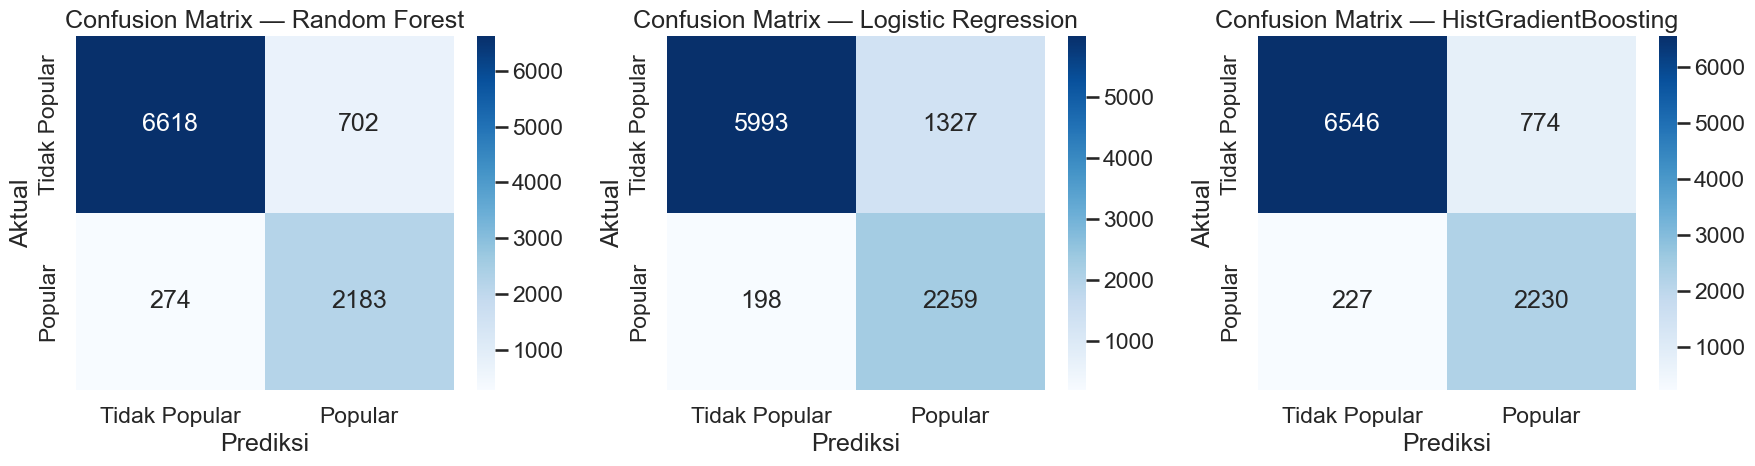

**Pertanyaan grafik:** Bagaimana perbandingan performa ketiga model untuk penyaringan properti?

**Interpretasi:**
- Dengan threshold yang disetel, ketiga model menunjukkan trade-off yang berbeda antara precision dan recall untuk kelas Popular.
- **HistGradientBoosting** memberikan hasil terbaik secara keseluruhan dengan F1-score tertinggi dan keseimbangan terbaik pada confusion matrix.
- Random Forest cenderung lebih seimbang, sedangkan Logistic Regression mungkin kesulitan menangkap interaksi non-linear yang kompleks.

In [7]:
section("Penyetelan Ambang Keputusan (Threshold Tuning) & Evaluasi 3 Model")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, pipe) in enumerate(models.items()):
    # Refit model pada seluruh training set
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Cari threshold optimal untuk memaksimalkan F1
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_thresh = thresholds[np.argmax(f1_scores)]
    best_f1_cv = np.max(f1_scores)

    y_pred_tuned = (y_proba >= best_thresh).astype(int)

    display(Markdown(f"### Classification Report — {name}"))
    print(f"Threshold optimal  : {best_thresh:.4f} | F1-score: {best_f1_cv:.4f}")
    print(classification_report(y_test, y_pred_tuned, target_names=["Tidak Popular", "Popular"]))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred_tuned)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Tidak Popular", "Popular"],
                yticklabels=["Tidak Popular", "Popular"], ax=axes[idx])
    axes[idx].set_xlabel("Prediksi")
    axes[idx].set_ylabel("Aktual")
    axes[idx].set_title(f"Confusion Matrix — {name}")

plt.tight_layout()
plt.show()

ask_plot("Bagaimana perbandingan performa ketiga model untuk penyaringan properti?")
explain_plot([
    "Dengan threshold yang disetel, ketiga model menunjukkan trade-off yang berbeda antara precision dan recall untuk kelas Popular.",
    f"**{best_name}** memberikan hasil terbaik secara keseluruhan dengan F1-score tertinggi dan keseimbangan terbaik pada confusion matrix.",
    "Random Forest cenderung lebih seimbang, sedangkan Logistic Regression mungkin kesulitan menangkap interaksi non-linear yang kompleks.",
])


## Kurva Evaluasi & Kepentingan Fitur

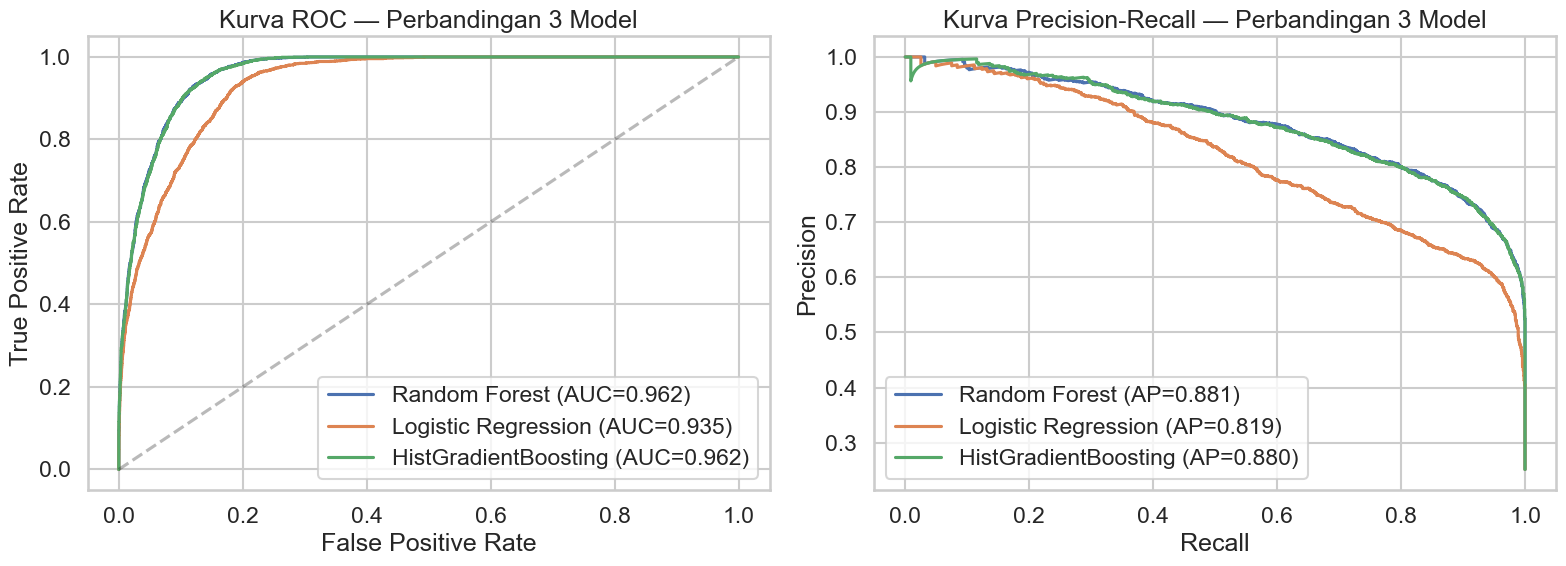

### Top-10 Fitur Paling Berpengaruh

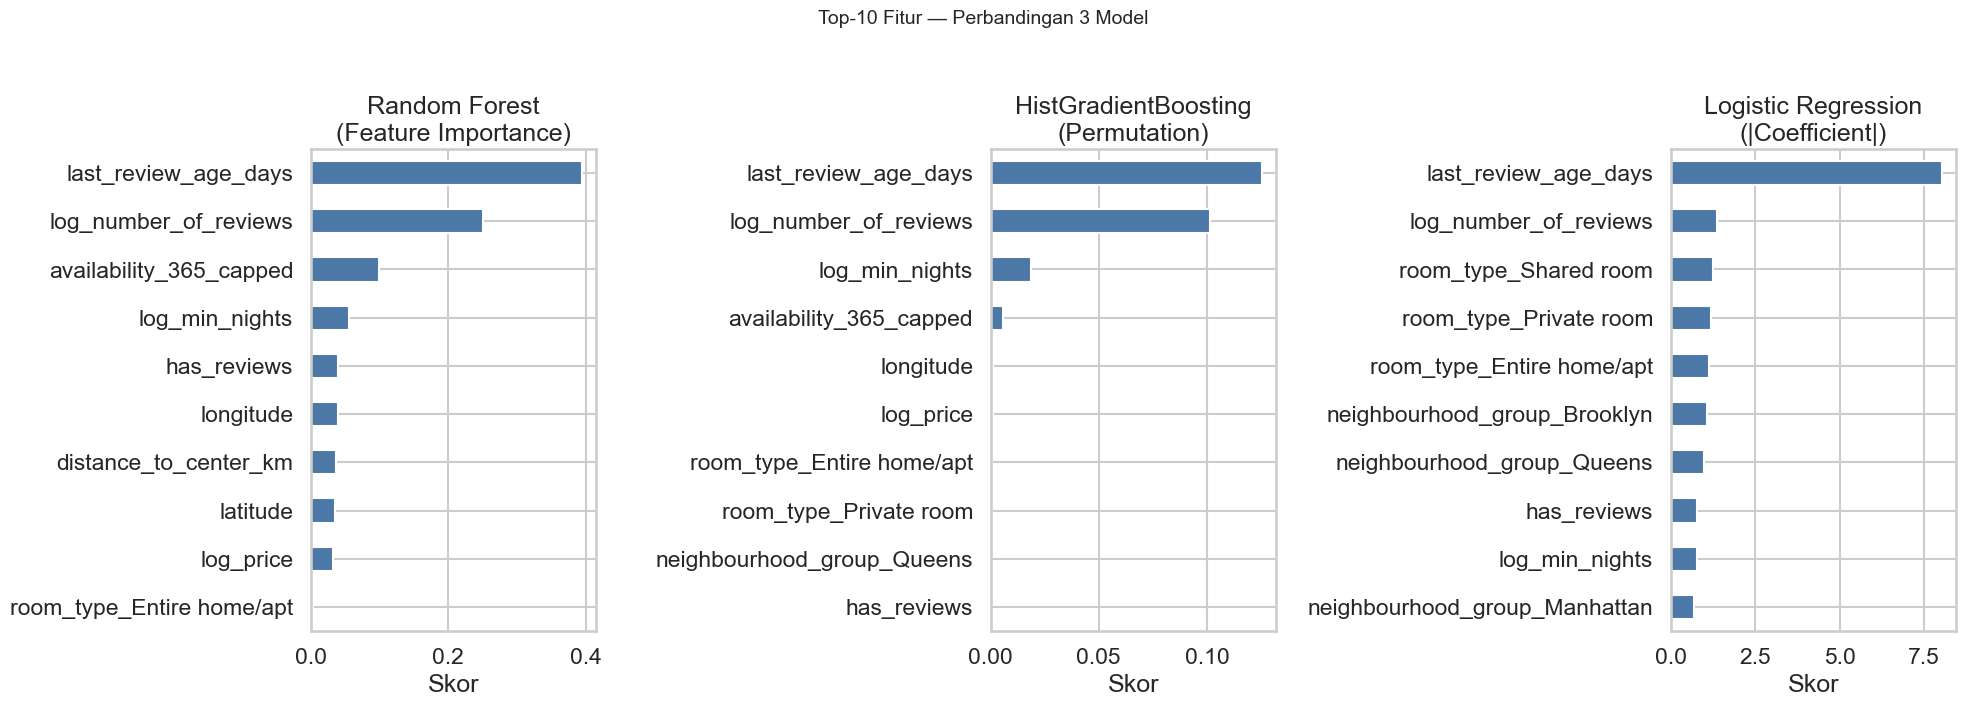

**Fitur yang konsisten di Top-10 ketiga model:** has_reviews, last_review_age_days, log_min_nights, log_number_of_reviews, room_type_Entire home/apt

**Pertanyaan grafik:** Fitur mana yang paling konsisten berpengaruh?

**Interpretasi:**
- Fitur yang muncul di top-10 pada ketiga model secara bersamaan adalah sinyal paling robust untuk popularitas.
- Perhatikan apakah fitur rekayasa (`distance_to_center_km`, `last_review_age_days`, `log_price`) berhasil masuk jajaran atas.

In [8]:
section("Kurva Evaluasi & Kepentingan Fitur")

# ── ROC + PR Curves (3-model overlay) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_p = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_p):.3f})")

    prec, rec, _ = precision_recall_curve(y_test, y_p)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, y_p):.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Kurva ROC — Perbandingan 3 Model")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Kurva Precision-Recall — Perbandingan 3 Model")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Feature Importance ──
display(Markdown("### Top-10 Fitur Paling Berpengaruh"))

# Nama fitur setelah encoding
preprocessor.fit(X_train)
encoded_names = (
    list(numeric_features)
    + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
)

# RF importance
rf_clf = models["Random Forest"].named_steps["clf"]
rf_clf.fit(preprocessor.transform(X_train), y_train)
rf_imp = pd.Series(rf_clf.feature_importances_, index=encoded_names).sort_values(ascending=True).tail(10)

# HGB permutation importance
hgb_pipe_fit = models["HistGradientBoosting"]
hgb_pipe_fit.fit(X_train, y_train)
X_test_enc = hgb_pipe_fit.named_steps["prep"].transform(X_test)
perm = permutation_importance(
    hgb_pipe_fit.named_steps["clf"], X_test_enc, y_test,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)
hgb_imp = pd.Series(perm.importances_mean, index=encoded_names).sort_values(ascending=True).tail(10)

# LR |coef|
lr_clf = models["Logistic Regression"].named_steps["clf"]
lr_clf.fit(preprocessor.transform(X_train), y_train)
lr_imp = pd.Series(np.abs(lr_clf.coef_[0]), index=encoded_names).sort_values(ascending=True).tail(10)

# Plot 3 side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (imp, title) in zip(axes, [
    (rf_imp, "Random Forest\n(Feature Importance)"),
    (hgb_imp, "HistGradientBoosting\n(Permutation)"),
    (lr_imp, "Logistic Regression\n(|Coefficient|)"),
]):
    imp.plot(kind="barh", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Skor")

plt.suptitle("Top-10 Fitur — Perbandingan 3 Model", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Cari fitur yang konsisten di top-10 semua model
common_features = set(rf_imp.index) & set(hgb_imp.index) & set(lr_imp.index)
display(Markdown(f"**Fitur yang konsisten di Top-10 ketiga model:** {', '.join(sorted(common_features)) if common_features else 'Tidak ada'}"))

ask_plot("Fitur mana yang paling konsisten berpengaruh?")
explain_plot([
    "Fitur yang muncul di top-10 pada ketiga model secara bersamaan adalah sinyal paling robust untuk popularitas.",
    "Perhatikan apakah fitur rekayasa (`distance_to_center_km`, `last_review_age_days`, `log_price`) berhasil masuk jajaran atas.",
])
